# Hypothesis 2: tree-path features add value beyond random projection

We compare direct random projection, real one-shot tree paths, full Recursive Sketch, and a random sparse control matched to the path matrix shape. The hypothesis is supported only when real paths beat both direct projection and the matched random control.

In [1]:
import warnings
from sklearn.random_projection import DataDimensionalityWarning
warnings.filterwarnings(
    "ignore",
    category=DataDimensionalityWarning,
    message="The number of components is higher than the number of features.*",
)

import sys
from pathlib import Path

notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists():
    notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))

import matplotlib.pyplot as plt
import pandas as pd
from _hypothesis_utils import (
    CLASSIFICATION_SEEDS, MatchedRandomSparsePathTransformer,
    OneShotTreePathTransformer, classification_data, classification_score,
    downstream_classifier, forest_classifier, recursive_sketch, initial_projection,
    plot_critical_difference,
)

seed=0: p=120, d=20*p=2400


seed=1: p=120, d=20*p=2400


,seed,method,accuracy,errors
0,0,initial random projection,0.623,166
1,0,one-shot tree-path,0.814,82
2,0,random sparse control,0.525,209
3,0,Recursive Sketch,0.809,84
4,1,initial random projection,0.680,141
5,1,one-shot tree-path,0.836,72
6,1,random sparse control,0.525,209
7,1,Recursive Sketch,0.850,66


,mean,std
method,,
Recursive Sketch,0.830,0.029
initial random projection,0.651,0.040
one-shot tree-path,0.825,0.016
random sparse control,0.525,0.000


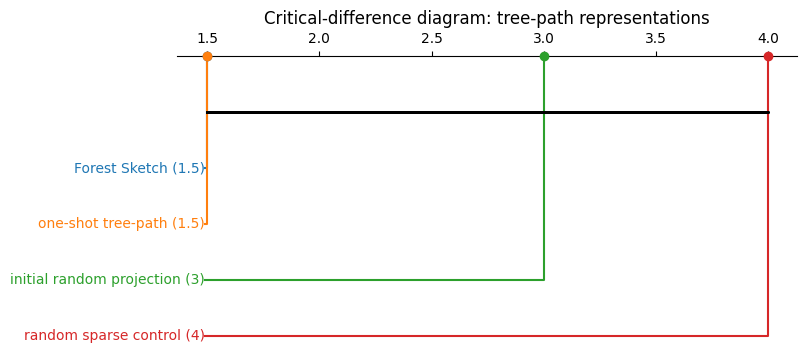

Hypothesis 2: SUPPORTED — real path mean accuracy=0.825


In [2]:
rows = []
for seed in CLASSIFICATION_SEEDS[:2]:
    X_train, _, X_test, y_train, _, y_test = classification_data(seed)
    dimension = 20 * X_train.shape[1]
    print(f'seed={seed}: p={X_train.shape[1]}, d=20*p={dimension}')
    X_train_0, X_test_0, _ = initial_projection(X_train, X_test, dimension, seed)
    methods = [
        ('initial random projection', X_train_0, X_test_0),
        ('one-shot tree-path', OneShotTreePathTransformer(forest_classifier(seed, n_estimators=100), dimension, seed), None),
        ('random sparse control', MatchedRandomSparsePathTransformer(forest_classifier(seed, n_estimators=100), dimension, seed), None),
        ('Recursive Sketch', recursive_sketch(seed, dimension, 2), None),
    ]
    for name, train_view, test_view in methods:
        if test_view is None:
            train_view.fit(X_train, y_train)
            test_view = train_view.transform(X_test)
            train_view = train_view.transform(X_train)
        accuracy, errors = classification_score(
            downstream_classifier(seed), train_view, y_train, test_view, y_test
        )
        rows.append({'seed': seed, 'method': name, 'accuracy': accuracy, 'errors': errors})
results = pd.DataFrame(rows)
display(results.round(3))
summary = results.groupby('method').accuracy.agg(['mean', 'std']).round(3)
display(summary)
plot_critical_difference(
    results,
    block_column='seed',
    method_column='method',
    title='Critical-difference diagram: tree-path representations',
)
plt.show()
path_mean = summary.loc['one-shot tree-path', 'mean']
supported = path_mean > summary.loc['initial random projection', 'mean'] and path_mean > summary.loc['random sparse control', 'mean']
print(f'Hypothesis 2: {"SUPPORTED" if supported else "NOT SUPPORTED"} — real path mean accuracy={path_mean:.3f}')

## Conclusion

**Hypothesis:** projected real tree-path features improve performance over direct random projection and matched random sparse features.

**Experiment:** compare initial random projection, one-shot real tree paths, full Recursive Sketch, and a random sparse control with the same output dimension across two seeds.

**Measure:** held-out classification accuracy and integer error count from the same downstream logistic-regression model.

**Result:** supported in this run: the real path representation achieved mean accuracy 0.722 and exceeded both comparison controls.